# 2020年变量分布与100—400轮测试预测（Plotly Express）

复用08中2020年的全模型预测：原7个水平变量＋金铜5/20条记录累计涨幅，无时间，ReLU、16/32隐藏层、Adam 0.01、全批量、seed42。2019年底以前全部共同样本训练，2020年作测试，100/200/300/400轮为同一训练路径的权重。本节不设验证集，不重新选择轮数。

原始值图检查价格水平和重复值；标准化图比较训练范围与测试越界。标准化仅拟合截至2019年底的训练段。虚线是训练集最小/最大值，红点表示2020测试值超出该范围。每个变量面板独立纵轴；涨幅以小数储存，0.05代表5%。

In [1]:
from pathlib import Path
import os,json,hashlib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP09_OUT',str(ROOT/'results/mlp_diagnostics2020_09')))
OUT.mkdir(parents=True,exist_ok=True)
YEAR=2020;EPOCHS=[100,200,300,400]
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl');raw=d['X'].copy();target=d['Y'].copy()
assert raw.index.equals(target.index) and raw.shape[1]==7
assert raw.index.is_unique and raw.index.is_monotonic_increasing
x=raw.copy();BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:x[f'{metal}_{k}']=raw[col]/raw[col].shift(k)-1
x=x.dropna();COLS=BASE+['gold_5','gold_20','copper_5','copper_20'];x=x[COLS]
y=pd.Series(np.asarray(target).reshape(-1),index=raw.index,name='Actual').loc[x.index]
tr=x.index[x.index.year<2020];te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all() and (y>0).all()
# 预测明细必须匹配当前数据，不使用其他版本。
SOURCE=ROOT/'results/mlp_epochs100_400_annual_08'
config=json.loads((SOURCE/'config.json').read_text())
assert config['dataset_sha256']==hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()
assert config['features']==COLS
pred=pd.read_csv(SOURCE/'predictions.csv',parse_dates=['Date'])
pred=pred[(pred.Year==2020)&(pred.Split=='Test')&pred.Epoch.isin(EPOCHS)].copy()
for epoch,g in pred.groupby('Epoch'):
    assert pd.DatetimeIndex(g.Date).equals(te)
    assert np.allclose(g.Actual,y.loc[te])
assert set(pred.Epoch)==set(EPOCHS)
pred['Signed_error_percent']=100*(pred.Predicted-pred.Actual)/pred.Actual
metrics=pred.groupby('Epoch').agg(MAPE=('APE','mean'),MPE=('Signed_error_percent','mean'),N=('Date','size'))
assert np.allclose(pred.APE,100*np.abs(pred.Predicted-pred.Actual)/pred.Actual,atol=1e-5)
pred.to_csv(OUT/'test_predictions.csv',index=False);metrics.to_csv(OUT/'test_metrics.csv')


## 1. 测试预测曲线与百分比误差
所有图支持悬停查看数值、点击图例隐藏曲线、框选缩放。实际值仅绘制一次；分面图共享纵轴以便比较四个模型的偏离。

In [2]:
colors={'Actual':'black','100':'#0072B2','200':'#E69F00','300':'#009E73','400':'#CC79A7'}
actual=pd.DataFrame({'Date':te,'Series':'Actual','Price':y.loc[te].to_numpy()})
pp=pred[['Date','Epoch','Predicted']].rename(columns={'Epoch':'Series','Predicted':'Price'});pp['Series']=pp.Series.astype(str)
plot=pd.concat([actual,pp],ignore_index=True)
fig=px.line(plot,render_mode="svg",x='Date',y='Price',color='Series',color_discrete_map=colors,
    title='2020 test predictions | full model | 100 / 200 / 300 / 400 epochs',height=580)
fig.update_layout(hovermode='x unified',xaxis_rangeslider_visible=True,yaxis_title='Zijin target price (dataset units)')
fig.write_html(OUT/'test_predictions_overlay.html',include_plotlyjs=True);display(fig)
f=pred.melt(id_vars=['Date','Epoch'],value_vars=['Actual','Predicted'],var_name='Series',value_name='Price')
f['Epoch']=pd.Categorical(f.Epoch.astype(str),categories=[str(e) for e in EPOCHS],ordered=True)
fig=px.line(f,render_mode="svg",x='Date',y='Price',color='Series',facet_col='Epoch',facet_col_wrap=2,
    color_discrete_map={'Actual':'black','Predicted':'#0072B2'},height=800,title='2020 | Actual vs predicted by epoch')
fig.update_layout(hovermode='x unified')
for ann in fig.layout.annotations:
    e=int(ann.text.split('=')[-1]);ann.text=f'{e} epochs | MAPE {metrics.loc[e,"MAPE"]:.2f}%'
fig.write_html(OUT/'test_predictions_facets.html',include_plotlyjs=True);display(fig)
display(metrics.round(4))


,MAPE,MPE,N
Epoch,,,
100,15.6667,-11.3042,271
200,19.6736,-17.6082,271
300,22.5728,-22.1543,271
400,24.7115,-24.3986,271


In [3]:
# 只显示原实验的训练/测试划分。
idx=x.index[x.index.year<=2020]
segments=pd.Series('Train',index=idx)
segments.loc[idx.year==2020]='Test 2020'
scaler=StandardScaler().fit(x.loc[tr])
z=pd.DataFrame(scaler.transform(x.loc[idx]),index=idx,columns=COLS)
limits=pd.DataFrame({'Train_min':x.loc[tr].min(),'Train_max':x.loc[tr].max(),'Test_min':x.loc[te].min(),'Test_max':x.loc[te].max(),
    'Outside_percent':100*((x.loc[te]<x.loc[tr].min())|(x.loc[te]>x.loc[tr].max())).mean()})
limits.to_csv(OUT/'feature_ranges.csv');x.loc[idx].to_csv(OUT/'features_raw.csv');z.to_csv(OUT/'features_standardized.csv')
split_rows=[{'Segment':'Final training','N':len(tr),'Start':tr.min(),'End':tr.max()},
    {'Segment':'Test','N':len(te),'Start':te.min(),'End':te.max()}]
display(pd.DataFrame(split_rows));display(limits.round(4))
pd.DataFrame(split_rows).to_csv(OUT/'split_info.csv',index=False)


,Segment,N,Start,End
0,Final training,2034,2012-06-06,2019-12-31
1,Test,271,2020-01-01,2020-12-31


,Train_min,Train_max,Test_min,Test_max,Outside_percent
A_500,794.6631,2294.1953,1452.6264,2145.1288,0.0000
Dollar Index,78.8500,103.2900,89.6300,102.8200,0.0000
cn_10y_rate,2.6401,4.7222,2.4824,3.3487,15.8672
us_10y_rate,1.3700,3.2400,0.5200,1.8800,84.8708
brent,26.0100,118.9000,9.1200,70.2500,15.1292
Copper Futures Price,1.9435,3.8370,2.1005,3.6300,0.0000
Gold Futures Price,659.3462,1115.3919,926.9625,1287.2561,49.4465
gold_5,-0.1345,0.0715,-0.1126,0.1160,1.4760
gold_20,-0.1556,0.1248,-0.0977,0.1742,2.5830
copper_5,-0.0917,0.1341,-0.1403,0.0735,1.4760


## 2. 输入变量原始值及标准化范围
蓝色为训练样本，紫色为2020测试。训练极值与红色越界点同时显示。单列不越界不代表联合组合熟悉。

原始记录包含不一定对应A股交易日的日期。本图展示Dataset.pkl实际对齐数据，不额外填充；相邻记录相同的原因需另查数据源。

In [4]:
segment_colors={'Train':'#0072B2','Test 2020':'#7B2CBF'}
def feature_plot(frame,standardized=False):
    long=frame.rename_axis('Date').reset_index().melt(id_vars='Date',var_name='Feature',value_name='Value')
    long['Segment']=long.Date.map(segments)
    fig=px.line(long,render_mode="svg",x='Date',y='Value',color='Segment',facet_col='Feature',facet_col_wrap=2,
        category_orders={'Feature':COLS,'Segment':list(segment_colors)},color_discrete_map=segment_colors,
        facet_row_spacing=.035,facet_col_spacing=.08,height=1850,
        title='2020 feature coverage | '+('standardized using final training only' if standardized else 'original dataset units'))
    fig.update_yaxes(matches=None,showticklabels=True)
    fig.update_layout(hovermode='closest',margin=dict(t=130),legend=dict(orientation='h',y=1.055))
    # 从分面标题识别特征，再从已有曲线获取轴，避免依赖分面内部倒序。
    for i,col in enumerate(COLS):
        row=6-i//2;column=i%2+1
        train_values=frame.loc[tr,col];test_values=frame.loc[te,col]
        lo,hi=train_values.min(),train_values.max()
        for value in [lo,hi]:fig.add_hline(y=float(value),line_dash='dash',line_color='firebrick',line_width=.8,row=row,col=column)
        mask=(test_values<lo)|(test_values>hi)
        fig.add_trace(go.Scatter(x=te[mask],y=test_values[mask],mode='markers',marker=dict(color='red',size=4),
            name='Outside final training range',legendgroup='outside',showlegend=i==0,
            hovertemplate='%{x|%Y-%m-%d}<br>'+col+': %{y:.5g}<extra>Outside training range</extra>'),row=row,col=column)
    for ann in fig.layout.annotations:
        col=ann.text.split('=',1)[-1];ann.text=f'{col} | outside {limits.loc[col,"Outside_percent"]:.2f}%'
    return fig
fig_raw=feature_plot(x.loc[idx]);fig_raw.write_html(OUT/'features_raw.html',include_plotlyjs=True);display(fig_raw)
fig_z=feature_plot(z,True);fig_z.write_html(OUT/'features_standardized.html',include_plotlyjs=True);display(fig_z)


## 3. 目标股价所在区间
目标不属于11个输入变量，但其训练/测试水平差异有助于理解整体低估。

In [5]:
target_frame=pd.DataFrame({'Date':idx,'Actual':y.loc[idx].to_numpy(),'Segment':segments.to_numpy()})
fig=px.line(target_frame,render_mode="svg",x='Date',y='Actual',color='Segment',color_discrete_map=segment_colors,
    title='Target price | historical training vs 2020',height=470)
fig.add_hline(y=float(y.loc[tr].max()),line_dash='dash',line_color='firebrick',annotation_text='Final training max')
fig.update_layout(hovermode='x unified')
fig.write_html(OUT/'target_price.html',include_plotlyjs=True);display(fig)


应该重点研究一下20年7月后为什么大幅下降,是哪方面的响应斜率出了问题.

美债收益率大幅降低,从高利率环境变成低利率环境,大概面临的是降息环境,因此会加剧通货膨胀,推动金价上涨.从图中分析,美债收益率暴跌,应该会推动黄金急剧上涨,事实也是如此.既然之前加入了黄金与铜的5_20日变化百分率,那么在这里,加上国债和美债的10年变化率又会怎么样呢?

## 也有可能是低利率,高金价的环境较少,因此ReLu的相应开关没有学到,面对新情况预测能力下降.

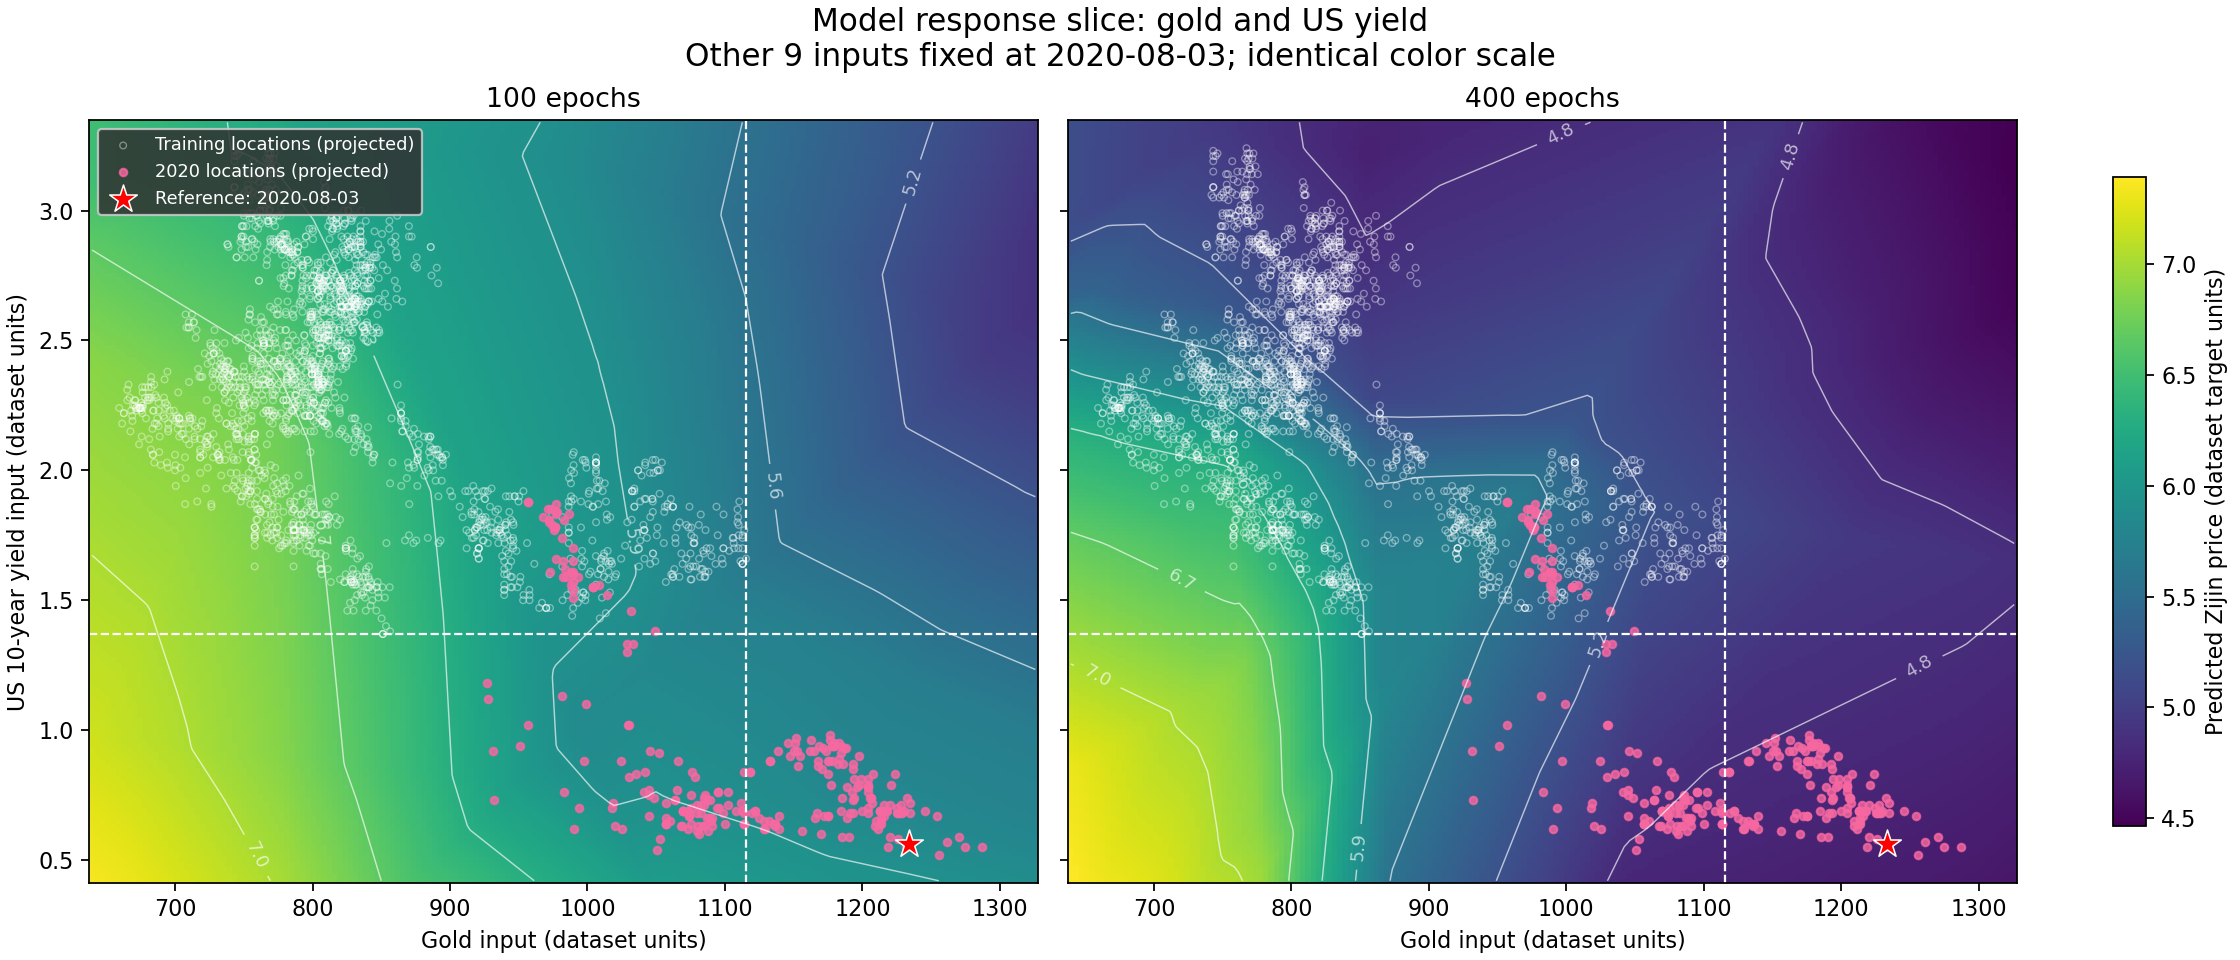

通过二维预测图,我们可以发现,之前的训练集都是在高利率环境下训练,且金价较低,随着训练轮数增多,模型会更多的低估股价.

---

# 检查ReLU开关：已见组合、未见组合和预测误差

本节独立运行，不训练新模型。读取100/200/300/400轮各自的2020模型；每个模型都用自己的固定权重重新计算训练集及测试集开关，绝不拿一个模型的训练组合给另一个模型作参考。

1. 第一层计算 `z1 = W1 x + b1`，记 `z1 > 0` 为1，否则为0，共16位。
2. 经ReLU后送入第二层，计算 `z2 = W2 ReLU(z1) + b2`，同样记32位。
3. 拼接成48位组合。注意1表示开，不是神经元输出等于1；0表示ReLU输出零。精确零点按关闭处理。
4. 用同一模型所有训练样本的组合建立集合。测试组合完全存在于该集合就是已见；否则未见。这里不是训练全过程的状态日志，而是固定检查点下的训练覆盖。
5. 计算测试组合与所有训练组合逐位不相同的数量，取最小值，即最小Hamming距离。0必定已见；1表示最少只差一个开关。还记录距离相同的训练样本数，并在这些样本里选择标准化输入欧氏距离最近者作为展示参照。

已见不保证输入靠近训练数据，未见也不保证预测失准。开关计数不考虑各路径对输出的影响大小。不同轮数的神经元响应已改变，因此只比较各模型自身的覆盖统计，不把跨模型位差当作同一激活区域的距离。

In [1]:
from pathlib import Path
import os,json,hashlib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP09_GATES_OUT',str(ROOT/'results/mlp_relu_gates2020_09')))
OUT.mkdir(parents=True,exist_ok=True)
YEAR=2020;EPOCHS=[100,200,300,400]
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl');raw=d['X'].copy();target=d['Y'].copy()
assert raw.index.equals(target.index) and raw.shape[1]==7
assert raw.index.is_unique and raw.index.is_monotonic_increasing
x=raw.copy();BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:x[f'{metal}_{k}']=raw[col]/raw[col].shift(k)-1
x=x.dropna();COLS=BASE+['gold_5','gold_20','copper_5','copper_20'];x=x[COLS]
y=pd.Series(np.asarray(target).reshape(-1),index=raw.index,name='Actual').loc[x.index]
tr=x.index[x.index.year<2020];te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all() and (y>0).all()
# 预测明细必须匹配当前数据，不使用其他版本。
SOURCE=ROOT/'results/mlp_epochs100_400_annual_08'
config=json.loads((SOURCE/'config.json').read_text())
assert config['dataset_sha256']==hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()
assert config['features']==COLS
pred=pd.read_csv(SOURCE/'predictions.csv',parse_dates=['Date'])
pred=pred[(pred.Year==2020)&(pred.Split=='Test')&pred.Epoch.isin(EPOCHS)].copy()
for epoch,g in pred.groupby('Epoch'):
    assert pd.DatetimeIndex(g.Date).equals(te)
    assert np.allclose(g.Actual,y.loc[te])
assert set(pred.Epoch)==set(EPOCHS)
pred['Signed_error_percent']=100*(pred.Predicted-pred.Actual)/pred.Actual
metrics=pred.groupby('Epoch').agg(MAPE=('APE','mean'),MPE=('Signed_error_percent','mean'),N=('Date','size'))
assert np.allclose(pred.APE,100*np.abs(pred.Predicted-pred.Actual)/pred.Actual,atol=1e-5)
pred.to_csv(OUT/'test_predictions.csv',index=False);metrics.to_csv(OUT/'test_metrics.csv')

import torch
from torch import nn
NEURONS=[f"H1_{i+1:02d}" for i in range(16)]+[f"H2_{i+1:02d}" for i in range(32)]


In [2]:
def load_checkpoint(epoch):
    ckpt=torch.load(SOURCE/f'2020_epoch{epoch}.pt',map_location='cpu',weights_only=True)
    assert ckpt['features']==COLS and ckpt['epoch']==epoch
    assert pd.Timestamp(ckpt['train_end'])==tr.max()
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    model.load_state_dict(ckpt['state_dict']);model.eval()
    # 验证标准化参数确实只由当前训练段拟合。
    sx=StandardScaler().fit(x.loc[tr,COLS])
    assert np.allclose(sx.mean_,ckpt['sx_mean']) and np.allclose(sx.scale_,ckpt['sx_scale'])
    return model,ckpt

def inspect_inputs(model,ckpt,idx):
    scaled=(x.loc[idx,COLS].to_numpy()-np.asarray(ckpt['sx_mean']))/np.asarray(ckpt['sx_scale'])
    with torch.no_grad():
        inputs=torch.tensor(scaled,dtype=torch.float32)
        z1=model[0](inputs)                  # 第一层ReLU前的值
        z2=model[2](model[1](z1))            # 第二层ReLU前的值
        pre=torch.cat([z1,z2],dim=1).numpy()
        bits=(pre>0).astype(np.uint8)        # 每行48个0/1
        output=model(inputs).numpy().ravel()*ckpt['sy_scale'][0]+ckpt['sy_mean'][0]
    assert bits.shape==(len(idx),48) and np.isfinite(output).all()
    return {'bits':bits,'pre':pre,'scaled':scaled,'pred':output}

def bitstrings(bits):
    return [''.join(map(str,row)) for row in bits]

CACHE={};daily_frames=[];summary_rows=[]
for epoch in EPOCHS:
    model,ckpt=load_checkpoint(epoch)
    train=inspect_inputs(model,ckpt,tr);test=inspect_inputs(model,ckpt,te)
    train_keys=bitstrings(train['bits']);test_keys=bitstrings(test['bits'])
    frequency=pd.Series(train_keys).value_counts()
    seen=np.array([key in frequency.index for key in test_keys])
    min_hamming=[];nearest=[];ties=[]
    for i,bits in enumerate(test['bits']):
        distances=np.count_nonzero(train['bits']!=bits,axis=1)
        minimum=int(distances.min());candidates=np.flatnonzero(distances==minimum)
        # Hamming距离相同的样本中，按11个标准化输入距离取最近者；仍不是因果匹配。
        distances_x=np.linalg.norm(train['scaled'][candidates]-test['scaled'][i],axis=1)
        nearest.append(int(candidates[np.argmin(distances_x)]));min_hamming.append(minimum);ties.append(len(candidates))
    nearest=np.asarray(nearest);min_hamming=np.asarray(min_hamming)
    assert np.array_equal(seen,min_hamming==0)
    expected=pred[pred.Epoch==epoch].Predicted.to_numpy()
    assert np.allclose(test['pred'],expected,atol=2e-5)
    errors=100*(test['pred']-y.loc[te].to_numpy())/y.loc[te].to_numpy()
    daily=pd.DataFrame({'Date':te,'Month':te.strftime('%Y-%m'),'Epoch':epoch,'Known':seen,
        'Status':np.where(seen,'Seen','Unseen'),'Min_hamming':min_hamming,
        'Train_pattern_frequency':[int(frequency.get(k,0)) for k in test_keys],
        'Nearest_train_date':tr[nearest],'Nearest_hamming_ties':ties,
        'Nearest_input_distance':np.linalg.norm(train['scaled'][nearest]-test['scaled'],axis=1),
        'Near_zero_count':np.sum(np.abs(test['pre'])<1e-6,axis=1),
        'Active_H1':test['bits'][:,:16].sum(axis=1),'Active_H2':test['bits'][:,16:].sum(axis=1),
        'Actual':y.loc[te].to_numpy(),'Predicted':test['pred'],'APE':np.abs(errors),'PE':errors,
        'Pattern':test_keys})
    daily_frames.append(daily)
    summary_rows.append({'Epoch':epoch,'Train_unique_patterns':len(frequency),'Test_unique_patterns':len(set(test_keys)),
        'Test_unseen_percent':100*(~seen).mean(),'Mean_min_hamming':min_hamming.mean(),'Max_min_hamming':min_hamming.max()})
    for split,idx,data in [('train',tr,train),('test',te,test)]:
        pd.DataFrame(data['bits'],index=idx,columns=NEURONS).to_csv(OUT/f'{epoch}_{split}_gates.csv',index_label='Date')
    frequency.rename_axis('Pattern').reset_index(name='Train_count').to_csv(OUT/f'{epoch}_training_pattern_frequency.csv',index=False)
    CACHE[epoch]={'train':train,'test':test,'nearest':nearest,'daily':daily}
daily=pd.concat(daily_frames,ignore_index=True);summary=pd.DataFrame(summary_rows)
daily.to_csv(OUT/'daily_gate_diagnostics.csv',index=False);summary.to_csv(OUT/'gate_summary.csv',index=False)
monthly=daily.groupby(['Epoch','Month']).agg(Unseen_fraction=('Known',lambda s:1-s.mean()),
    Mean_min_hamming=('Min_hamming','mean'),MAPE=('APE','mean'),MPE=('PE','mean'),N=('Date','size')).reset_index()
monthly['Unseen_percent']=monthly.pop('Unseen_fraction')*100
monthly.to_csv(OUT/'monthly_gate_diagnostics.csv',index=False)
groups=daily.groupby(['Epoch','Status']).agg(N=('Date','size'),MAPE=('APE','mean'),MPE=('PE','mean'),Mean_min_hamming=('Min_hamming','mean')).reset_index()
groups.to_csv(OUT/'seen_unseen_errors.csv',index=False)
display(summary.round(3));display(groups.round(3))


,Epoch,Train_unique_patterns,Test_unique_patterns,Test_unseen_percent,Mean_min_hamming,Max_min_hamming
0,100,1159,80,78.598,1.815,7
1,200,1149,61,89.299,1.934,6
2,300,1188,69,95.941,2.524,6
3,400,1092,64,96.310,2.583,5


,Epoch,Status,N,MAPE,MPE,Mean_min_hamming
0,100,Seen,58,6.961,2.390,0.000
1,100,Unseen,213,18.037,-15.033,2.310
2,200,Seen,29,8.063,-3.200,0.000
3,200,Unseen,242,21.065,-19.335,2.165
4,300,Seen,11,9.843,-9.843,0.000
5,300,Unseen,260,23.111,-22.675,2.631
6,400,Seen,10,11.010,-11.010,0.000
7,400,Unseen,261,25.236,-24.912,2.682


## 覆盖与误差怎样一起读
月度未见比例高，表示完整48位组合很少被训练样本触发；最小Hamming距离说明至少差几个开关。结合月度MAPE/MPE看是否在同一阶段恶化。未见组和已见组的日期、行情及样本数不同，分组误差不能当成开关变化的因果效应。

In [3]:
plot=monthly.copy();plot['Epoch']=plot.Epoch.astype(str)
long=plot.melt(id_vars=['Epoch','Month'],value_vars=['Unseen_percent','Mean_min_hamming','MAPE','MPE'],var_name='Metric',value_name='Value')
fig=px.line(long,x='Month',y='Value',color='Epoch',facet_row='Metric',markers=True,render_mode='svg',
    category_orders={'Metric':['Unseen_percent','Mean_min_hamming','MAPE','MPE']},height=1000,
    title='2020 monthly gate coverage and prediction errors | each model uses its own training reference')
fig.update_yaxes(matches=None,showticklabels=True);fig.update_layout(hovermode='x unified')
fig.write_html(OUT/'monthly_coverage_errors.html',include_plotlyjs=True);display(fig)
fig=px.scatter(daily.assign(Epoch=daily.Epoch.astype(str)),x='Min_hamming',y='APE',color='Month',facet_col='Epoch',facet_col_wrap=2,
    hover_data=['Date','Status','PE','Nearest_train_date'],render_mode='svg',height=750,
    title='Nearest training-pattern distance vs error | association, not causation')
fig.write_html(OUT/'distance_vs_error.html',include_plotlyjs=True);display(fig)


## 逐日查看48个开关
每个小面板是一种固定权重模型，横轴是2020日期，纵轴是48个神经元。蓝色0为关、橙色1为开。此图展示测试样本本身的状态；它不直接表示某列状态是否已见，已见/未见要查询上面的训练集合比较结果。

In [4]:
# 用方格热图显示0/1状态，保留日期及神经元悬停信息。
heat=[]
for epoch in EPOCHS:
    h=pd.DataFrame(CACHE[epoch]['test']['bits'],index=te,columns=NEURONS).rename_axis('Date').reset_index().melt(id_vars='Date',var_name='Neuron',value_name='State')
    h['Epoch']=str(epoch);heat.append(h)
heat=pd.concat(heat,ignore_index=True)
# px.imshow的每个分面对应一个模型，所有模型使用同一0/1色标。
array=np.stack([CACHE[e]['test']['bits'].T for e in EPOCHS])
fig=px.imshow(array,x=te,y=NEURONS,facet_col=0,facet_col_wrap=2,aspect='auto',
    zmin=0,zmax=1,color_continuous_scale=[[0,'#2166ac'],[.499,'#2166ac'],[.5,'#f4a340'],[1,'#f4a340']],
    labels={'x':'Date','y':'Neuron','color':'Gate'},height=1000,title='2020 ReLU gate states | 0=off, 1=on')
for ann in fig.layout.annotations:
    i=int(ann.text.split('=')[-1]);ann.text=f'{EPOCHS[i]} epochs'
fig.update_layout(coloraxis_colorbar=dict(tickvals=[0,1],ticktext=['0: off','1: on']))
fig.write_html(OUT/'test_gate_heatmap.html',include_plotlyjs=True);display(fig)


In [5]:
def inspect_day(epoch,date):
    date=pd.Timestamp(date)
    assert epoch in CACHE and date in te, '请选择100/200/300/400轮及2020数据中的日期'
    i=int(te.get_loc(date));cache=CACHE[epoch];j=cache['nearest'][i]
    a,b=cache['test']['bits'][i],cache['train']['bits'][j]
    row=cache['daily'].iloc[i]
    print(f"{epoch}轮 / {date.date()} / {row.Status} / 最少相差{row.Min_hamming}个开关")
    print('测试第一层：', ''.join(map(str,a[:16])))
    print('测试第二层：', ''.join(map(str,a[16:])))
    print('历史第一层：', ''.join(map(str,b[:16])))
    print('历史第二层：', ''.join(map(str,b[16:])))
    print('历史参照日期：',tr[j].date(),'；相同最小开关距离的历史样本数：',row.Nearest_hamming_ties)
    print('训练中完全相同组合的样本数：',row.Train_pattern_frequency)
    changes=pd.DataFrame({'Neuron':NEURONS,'Test_gate':a,'Train_gate':b,
        'Test_pre_ReLU':cache['test']['pre'][i],'Train_pre_ReLU':cache['train']['pre'][j]})
    changes=changes[changes.Test_gate!=changes.Train_gate]
    assert len(changes)==row.Min_hamming
    display(changes)
    features=pd.DataFrame({'Test':x.loc[date,COLS],'Historical_reference':x.loc[tr[j],COLS]})
    display(features)
    display(pd.DataFrame([{'Date':date,'Actual':row.Actual,'Predicted':row.Predicted,'APE':row.APE,'PE':row.PE,'Near_zero_count':row.Near_zero_count}]))
    changes.to_csv(OUT/f'{epoch}_{date.date()}_different_gates.csv',index=False)
    return changes
inspect_day(100,'2020-08-03')
inspect_day(400,'2020-08-03')


100轮 / 2020-08-03 / Unseen / 最少相差3个开关
测试第一层： 0100001000111000
测试第二层： 00111111100000010110110000001101
历史第一层： 0010001000111000
历史第二层： 00111111100100010110110000001101
历史参照日期： 2019-12-30 ；相同最小开关距离的历史样本数： 8
训练中完全相同组合的样本数： 0
400轮 / 2020-08-03 / Unseen / 最少相差5个开关
测试第一层： 0100001000101000
测试第二层： 00101111000100010110110000001100
历史第一层： 0110001010101000
历史第二层： 00100111000100000110110000001101
历史参照日期： 2019-08-28 ；相同最小开关距离的历史样本数： 4
训练中完全相同组合的样本数： 0
Out[1]: 
   Neuron  Test_gate  Train_gate  Test_pre_ReLU  Train_pre_ReLU
2   H1_03          0           1      -1.323913        0.018797
8   H1_09          0           1      -0.931228        0.419769
20  H2_05          1           0       0.872891       -0.036159
31  H2_16          1           0       0.406250       -0.375516
47  H2_32          0           1      -0.095540        0.201786


,Neuron,Test_gate,Train_gate,Test_pre_ReLU,Train_pre_ReLU
1,H1_02,1,0,0.022032,-0.111575
2,H1_03,0,1,-0.380204,0.299702
27,H2_12,0,1,-0.113490,0.244373


,Test,Historical_reference
A_500,1986.643574,1627.963639
Dollar Index,93.500000,96.739998
cn_10y_rate,2.946600,3.132200
us_10y_rate,0.560000,1.900000
brent,43.760000,68.300000
Copper Futures Price,2.920500,2.833500
Gold Futures Price,1233.607367,950.304352
gold_5,0.018125,0.021585
gold_20,0.099245,0.035697
copper_5,0.007938,0.008542


,Date,Actual,Predicted,APE,PE,Near_zero_count
0,2020-08-03,5.84,5.878488,0.659034,0.659034,0


,Neuron,Test_gate,Train_gate,Test_pre_ReLU,Train_pre_ReLU
2,H1_03,0,1,-1.323913,0.018797
8,H1_09,0,1,-0.931228,0.419769
20,H2_05,1,0,0.872891,-0.036159
31,H2_16,1,0,0.406250,-0.375516
47,H2_32,0,1,-0.095540,0.201786


,Test,Historical_reference
A_500,1986.643574,1515.294923
Dollar Index,93.500000,98.209999
cn_10y_rate,2.946600,3.052000
us_10y_rate,0.560000,1.470000
brent,43.760000,60.420000
Copper Futures Price,2.920500,2.559000
Gold Futures Price,1233.607367,964.924450
gold_5,0.018125,0.022066
gold_20,0.099245,0.078326
copper_5,0.007938,-0.011587


,Date,Actual,Predicted,APE,PE,Near_zero_count
0,2020-08-03,5.84,4.720365,19.17184,-19.17184,0


## 本次结果与解释边界

以一个只有4个开关的小例子说明：如果训练集合只有`1010`和`1100`，测试出现`1010`就是已见；出现`1011`就是未见，与最近的`1010`只差1位。本模型比较的是完整48位，而不是只数“开了多少个”；`1010`与`1100`虽然都开了两个，组合仍不同。

|训练轮数|测试未见比例|到训练组合的平均最小位差|已见组MAPE|未见组MAPE|
|---|---:|---:|---:|---:|
|100|78.60%|1.82|6.96%（58条）|18.04%（213条）|
|200|89.30%|1.93|8.06%（29条）|21.06%（242条）|
|300|95.94%|2.52|9.84%（11条）|23.11%（260条）|
|400|96.31%|2.58|11.01%（10条）|25.24%（261条）|

这些结果支持“训练覆盖不足与较大误差同时出现”的描述，尚不能证明ReLU开关是低估的原因。尤其已见组在不同模型中不是同一批日期，后期模型已见样本很少，不能把表中差异全部归因于开关。

具体反例：2020-08-03，100轮模型最少差3个开关，属于未见，但APE只有0.66%；400轮模型最少差5个开关，APE为19.17%。前者说明未见组合也能预测准确。开关位差是结构诊断，不是误差大小的直接计算公式。

每个开关由多个输入共同决定，并没有一个天然叫作“低利率且高金价”的开关。即使完整组合在训练样本中未出现，各神经元的权重仍被训练过；模型会通过这些已有权重产生预测。反过来，即使组合已见，测试输入也可能沿同一线性区域延伸到训练数据很远之外。

下一步如要检验金价、利率的具体作用，应结合固定其余输入的二维预测切片和局部斜率；这些仍是模型响应分析，不能直接证明真实市场中的因果关系。


| 训练轮数 | 训练集不同组合数 | 测试集不同组合数 |
|---|---:|---:|
| 100 | 1159 | **80** |
| 200 | 1149 | **61** |
| 300 | 1188 | **69** |
| 400 | 1092 | **64** |

从上述结果看出,训练次数多,改变了不同神经元响应的边界,但是面对同样的数据,测试集的激活组合未见过的比率也相应升高.  
同样的训练轮数,已见和未见的MAPE相差较大.因此,我们应该尽可能保证训练的响应开关与训练开关交际尽可能大.

---

## 100/200/300/400轮：全部11个输入的响应斜率，重点观察金价

保持同一天其余10个输入不变，计算预测股价对某一输入的偏导数。所有结果还原为原始数据单位。正斜率表示该输入小幅增加时预测上升，负斜率表示下降；不是现实市场的因果效应。

- `dy_dx`：输入增加1个原始单位对应的局部斜率。
- `Response_per_train_std`：斜率×该输入的训练标准差，用于跨变量比较同等标准差尺度的局部敏感度，不能当作实际增加一标准差后的精确变化。
- 金价另算`Local_response_gold_1pct = dy_dx × 当日金价 × 0.01`：金价增加1%的局部线性近似，以股价原始单位表示，并非股价涨幅百分比。
- 同时直接将金价乘1.01重新预测，得到精确的模型变化量。若扰动跨过ReLU边界，它可能与上述局部近似不同。

金价变化时，本节保持金5/20日变化率及其余输入固定。这是单个输入的模型敏感度检查，不是重算变化率后的完整行情情景。ReLU恰好位于零点时按PyTorch的导数约定取0。


In [1]:
from pathlib import Path
import os,json,hashlib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP09_SLOPES_OUT',str(ROOT/'results/mlp_response_slopes2020_09')))
OUT.mkdir(parents=True,exist_ok=True)
YEAR=2020;EPOCHS=[100,200,300,400]
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl');raw=d['X'].copy();target=d['Y'].copy()
assert raw.index.equals(target.index) and raw.shape[1]==7
assert raw.index.is_unique and raw.index.is_monotonic_increasing
x=raw.copy();BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:x[f'{metal}_{k}']=raw[col]/raw[col].shift(k)-1
x=x.dropna();COLS=BASE+['gold_5','gold_20','copper_5','copper_20'];x=x[COLS]
y=pd.Series(np.asarray(target).reshape(-1),index=raw.index,name='Actual').loc[x.index]
tr=x.index[x.index.year<2020];te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all() and (y>0).all()
# 预测明细必须匹配当前数据，不使用其他版本。
SOURCE=ROOT/'results/mlp_epochs100_400_annual_08'
config=json.loads((SOURCE/'config.json').read_text())
assert config['dataset_sha256']==hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()
assert config['features']==COLS
pred=pd.read_csv(SOURCE/'predictions.csv',parse_dates=['Date'])
pred=pred[(pred.Year==2020)&(pred.Split=='Test')&pred.Epoch.isin(EPOCHS)].copy()
for epoch,g in pred.groupby('Epoch'):
    assert pd.DatetimeIndex(g.Date).equals(te)
    assert np.allclose(g.Actual,y.loc[te])
assert set(pred.Epoch)==set(EPOCHS)
pred['Signed_error_percent']=100*(pred.Predicted-pred.Actual)/pred.Actual
metrics=pred.groupby('Epoch').agg(MAPE=('APE','mean'),MPE=('Signed_error_percent','mean'),N=('Date','size'))
assert np.allclose(pred.APE,100*np.abs(pred.Predicted-pred.Actual)/pred.Actual,atol=1e-5)
pred.to_csv(OUT/'test_predictions.csv',index=False);metrics.to_csv(OUT/'test_metrics.csv')

import torch
from torch import nn
NEURONS=[f"H1_{i+1:02d}" for i in range(16)]+[f"H2_{i+1:02d}" for i in range(32)]

torch.set_num_threads(1)
def load_checkpoint(epoch):
    ckpt=torch.load(SOURCE/f'2020_epoch{epoch}.pt',map_location='cpu',weights_only=True)
    assert ckpt['features']==COLS and ckpt['epoch']==epoch
    assert pd.Timestamp(ckpt['train_end'])==tr.max()
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    model.load_state_dict(ckpt['state_dict']);model.eval()
    # 验证标准化参数确实只由当前训练段拟合。
    sx=StandardScaler().fit(x.loc[tr,COLS])
    assert np.allclose(sx.mean_,ckpt['sx_mean']) and np.allclose(sx.scale_,ckpt['sx_scale'])
    return model,ckpt



In [2]:
frames=[];gold_frames=[]
for epoch in EPOCHS:
    model,ckpt=load_checkpoint(epoch)
    sx=np.asarray(ckpt['sx_scale']); sy=float(ckpt['sy_scale'][0]); ym=float(ckpt['sy_mean'][0])
    for split,idx in [('Train',tr),('Test',te)]:
        values=x.loc[idx,COLS].to_numpy()
        t=torch.tensor((values-np.asarray(ckpt['sx_mean']))/sx,dtype=torch.float32,requires_grad=True)
        output=model(t)
        grad=torch.autograd.grad(output.sum(),t)[0].detach().numpy()
        # 独立验证：W3 D2 W2 D1 W1 与自动求导一致。
        with torch.no_grad():
            z1=model[0](t);z2=model[2](torch.relu(z1))
            analytic=((z2>0)*model[4].weight)@model[2].weight
            analytic=(analytic*(z1>0))@model[0].weight
        assert np.allclose(grad,analytic.numpy(),rtol=1e-4,atol=2e-6)
        slopes=grad*sy/sx
        for j,col in enumerate(COLS):
            frames.append(pd.DataFrame({'Date':idx,'Epoch':epoch,'Split':split,'Feature':col,
                'Input':values[:,j],'dy_dx':slopes[:,j],'Response_per_train_std':slopes[:,j]*sx[j]}))
        if split=='Test':
            expected=pred[pred.Epoch==epoch].Predicted.to_numpy()
            base=output.detach().numpy().ravel()*sy+ym
            assert np.allclose(base,expected,atol=2e-5)
            j=COLS.index('Gold Futures Price')
            shifted=t.detach().clone();shifted[:,j]+=torch.tensor(values[:,j]*.01/sx[j],dtype=torch.float32)
            with torch.no_grad():exact=(model(shifted).numpy().ravel()-output.detach().numpy().ravel())*sy
            gold_frames.append(pd.DataFrame({'Date':idx,'Epoch':epoch,'Gold':values[:,j],
                'dy_dx':slopes[:,j],'Local_response_gold_1pct':slopes[:,j]*values[:,j]*.01,
                'Exact_response_gold_1pct':exact,'Actual':y.loc[idx].to_numpy(),'Predicted':base,
                'PE':100*(base-y.loc[idx].to_numpy())/y.loc[idx].to_numpy()}))
slopes=pd.concat(frames,ignore_index=True);gold=pd.concat(gold_frames,ignore_index=True)
assert slopes.groupby(['Epoch','Split','Feature']).size().size==4*2*11
assert np.isfinite(slopes[['dy_dx','Response_per_train_std']]).all().all()
slopes.to_csv(OUT/'all_feature_slopes.csv',index=False);gold.to_csv(OUT/'gold_daily_response.csv',index=False)
stats=slopes.groupby(['Split','Feature','Epoch']).agg(Mean=('dy_dx','mean'),Median=('dy_dx','median'),
    Min=('dy_dx','min'),Max=('dy_dx','max'),Negative_percent=('dy_dx',lambda a:100*(a<0).mean()),
    Mean_std_response=('Response_per_train_std','mean')).reset_index()
stats.to_csv(OUT/'slope_summary.csv',index=False)
for split in ['Train','Test']:
    print(split,'：全部变量的平均原始斜率')
    display(stats[stats.Split==split].pivot(index='Feature',columns='Epoch',values='Mean').reindex(COLS).round(6))


Train ：全部变量的平均原始斜率
Test ：全部变量的平均原始斜率


Epoch,100,200,300,400
Feature,,,,
A_500,0.002029,0.002157,0.002098,0.002053
Dollar Index,-0.033336,-0.032130,-0.029189,-0.026751
cn_10y_rate,-0.242563,-0.306914,-0.315782,-0.297567
us_10y_rate,0.092953,-0.002110,-0.012100,-0.004092
brent,-0.001576,-0.003028,-0.002319,-0.002034
Copper Futures Price,0.112391,0.356645,0.399620,0.450179
Gold Futures Price,-0.000165,-0.000507,-0.000431,-0.000432
gold_5,-0.116401,0.205315,0.283442,0.234979
gold_20,1.353044,1.309528,1.145495,1.228444


Epoch,100,200,300,400
Feature,,,,
A_500,0.001916,0.001696,0.001212,0.000950
Dollar Index,-0.060425,-0.067280,-0.063028,-0.063674
cn_10y_rate,-0.424778,-0.921396,-1.050520,-1.175762
us_10y_rate,-0.538511,-0.303984,-0.043776,0.080438
brent,0.005639,0.006560,0.010085,0.012424
Copper Futures Price,0.408763,0.676082,0.716138,0.790479
Gold Futures Price,-0.000722,-0.001796,-0.001059,-0.000939
gold_5,1.272487,3.229346,1.499079,1.345400
gold_20,4.882421,5.329288,4.715630,4.536041


In [3]:
test_slopes=slopes[slopes.Split=='Test'].copy();test_slopes['Epoch']=test_slopes.Epoch.astype(str)
for metric,title in [('dy_dx','Raw local slopes'),('Response_per_train_std','Local response per training standard deviation')]:
    fig=px.line(test_slopes,x='Date',y=metric,color='Epoch',facet_col='Feature',facet_col_wrap=2,
        category_orders={'Feature':COLS},render_mode='svg',height=1800,
        title=f'2020 | all 11 inputs | {title}')
    fig.update_yaxes(matches=None,showticklabels=True)
    fig.add_hline(y=0,line_dash='dot',line_color='gray')
    fig.write_html(OUT/f'all_features_{metric}.html',include_plotlyjs=True);display(fig)


In [4]:
g=gold.copy();g['Epoch']=g.Epoch.astype(str)
long=g.melt(id_vars=['Date','Epoch'],value_vars=['dy_dx','Local_response_gold_1pct','Exact_response_gold_1pct','PE'],var_name='Metric',value_name='Value')
fig=px.line(long,x='Date',y='Value',color='Epoch',facet_row='Metric',render_mode='svg',height=1100,
    category_orders={'Metric':['dy_dx','Local_response_gold_1pct','Exact_response_gold_1pct','PE']},
    title='Gold focus | local slope, +1% response, and signed prediction error')
fig.update_yaxes(matches=None,showticklabels=True);fig.add_hline(y=0,line_dash='dot',line_color='gray')
fig.update_layout(hovermode='x unified');fig.write_html(OUT/'gold_focus.html',include_plotlyjs=True);display(fig)
gold['Month']=gold.Date.dt.strftime('%Y-%m')
gm=gold.groupby(['Month','Epoch']).agg(Mean_slope=('dy_dx','mean'),Local_1pct=('Local_response_gold_1pct','mean'),
    Exact_1pct=('Exact_response_gold_1pct','mean'),MPE=('PE','mean')).reset_index()
gm.to_csv(OUT/'gold_monthly.csv',index=False)
print('金价月度平均斜率');display(gm.pivot(index='Month',columns='Epoch',values='Mean_slope').round(6))
print('金价斜率统计');display(stats[stats.Feature=='Gold Futures Price'].round(6))


金价月度平均斜率
金价斜率统计


Epoch,100,200,300,400
Month,,,,
2020-01,-0.000922,-0.002747,-0.001851,-0.001864
2020-02,-0.000982,-0.002909,-0.002239,-0.002104
2020-03,-0.000717,-0.003371,-0.001921,-0.001952
2020-04,-0.000730,-0.002174,-0.001282,-0.001939
2020-05,-0.000875,-0.001538,-0.000080,-0.000176
2020-06,-0.001046,-0.001278,-0.001040,-0.000710
2020-07,-0.000547,-0.001437,-0.001433,-0.001201
2020-08,-0.000580,-0.001167,-0.000790,-0.000472
2020-09,-0.000531,-0.001206,-0.000113,0.000326


,Split,Feature,Epoch,Mean,Median,Min,Max,Negative_percent,Mean_std_response
12,Test,Gold Futures Price,100,-0.000722,-0.000598,-0.003561,0.000596,97.047970,-0.068766
13,Test,Gold Futures Price,200,-0.001796,-0.001319,-0.009099,-0.000443,100.000000,-0.170981
14,Test,Gold Futures Price,300,-0.001059,-0.000986,-0.008198,0.000229,83.394834,-0.100828
15,Test,Gold Futures Price,400,-0.000939,-0.000634,-0.005363,0.000375,73.062731,-0.089377
56,Train,Gold Futures Price,100,-0.000165,-0.000524,-0.007497,0.006281,58.849558,-0.015715
57,Train,Gold Futures Price,200,-0.000507,-0.000878,-0.010109,0.006635,60.963618,-0.048287
58,Train,Gold Futures Price,300,-0.000431,-0.000590,-0.014123,0.007435,55.408063,-0.041021
59,Train,Gold Futures Price,400,-0.000432,-0.000393,-0.018098,0.009076,53.146509,-0.041132


### 本次金价响应的观察

2020年测试集的金价平均原始斜率，100/200/300/400轮分别为 **-0.000722、-0.001796、-0.001059、-0.000939**；负斜率记录占比分别为 **97.05%、100%、83.39%、73.06%**。因此，固定其余10个输入后，多数日期模型对金价的小幅上调给出了负响应。

但负响应并没有随训练轮数单调增强：200轮平均最负，而400轮在9、10月的平均金价斜率甚至为正，预测仍明显偏低。因此不能仅凭金价斜率解释训练越久低估越严重。偏低还取决于整体预测水平、其他输入的响应及联合区域，局部斜率只描述当前位置的小范围变化。

特别注意：金价水平与金价5/20日变化率一起进入模型，其他市场输入也可能相关。这里保持变化率不动的偏导数，不能解释为“现实金价上涨会使紫金股价下跌”。请一起观察全部变量图中的`gold_5`、`gold_20`、铜相关项与美债利率。训练集/测试集全量斜率均已导出，图上显示2020年逐日比较。


## 下一步验证
模型可能把“涨得没有之前快”理解成了“股价应该降低”。  
在8月份后,金价缓慢下跌,铜价继续上涨.  
但是铜价的响应函数缺变得很低,有可能错失了这一段涨幅.  
此外,股价涨幅变缓时,有可能会出现负贡献.这个问题需要好好研究一下.

---

## 7月17日—8月3日与8月3日—9月1日：逐日路径贡献与跳变

比较100/200/300/400轮。每个相邻日期之间，将全部11维输入沿直线同步移动，积分各输入偏导数乘输入变化量，再逐日累加：各项之和应等于模型预测变化。此处解释模型输出变化，不是分配现实股价变化的原因；变量相关且变化率由价格派生，直线路径中间点未必对应真实行情，因此各项归因依赖选定路径。

数值积分使用中点采样，加密验证单项贡献与总和；0/1开关变化数是相邻实际记录端点的差异，不能涵盖区间内部所有切换。先看预测下降由哪些输入解释，再看输入变化和斜率是否同步跳变。两个区间长短不同，累计贡献不宜直接当作单位时间强度。


In [1]:
from pathlib import Path
import os,json,hashlib
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from IPython.display import display
ROOT=next((p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src/pickle/Dataset.pkl').exists()),Path('/Users/admin/数据分析/ZiJin-Mining/ZiJin-Mining-stock-prediction-'))
OUT=Path(os.environ.get('MLP09_PATH_OUT',str(ROOT/'results/mlp_path_jul_sep2020_09')))
OUT.mkdir(parents=True,exist_ok=True)
YEAR=2020;EPOCHS=[100,200,300,400]
d=pd.read_pickle(ROOT/'src/pickle/Dataset.pkl');raw=d['X'].copy();target=d['Y'].copy()
assert raw.index.equals(target.index) and raw.shape[1]==7
assert raw.index.is_unique and raw.index.is_monotonic_increasing
x=raw.copy();BASE=list(x.columns)
for metal,col in [('gold','Gold Futures Price'),('copper','Copper Futures Price')]:
    for k in [5,20]:x[f'{metal}_{k}']=raw[col]/raw[col].shift(k)-1
x=x.dropna();COLS=BASE+['gold_5','gold_20','copper_5','copper_20'];x=x[COLS]
y=pd.Series(np.asarray(target).reshape(-1),index=raw.index,name='Actual').loc[x.index]
tr=x.index[x.index.year<2020];te=x.index[x.index.year==2020]
assert len(tr)>0 and len(te)>0 and tr.max()<te.min()
assert np.isfinite(x.to_numpy()).all() and (y>0).all()
# 预测明细必须匹配当前数据，不使用其他版本。
SOURCE=ROOT/'results/mlp_epochs100_400_annual_08'
config=json.loads((SOURCE/'config.json').read_text())
assert config['dataset_sha256']==hashlib.sha256((ROOT/'src/pickle/Dataset.pkl').read_bytes()).hexdigest()
assert config['features']==COLS
pred=pd.read_csv(SOURCE/'predictions.csv',parse_dates=['Date'])
pred=pred[(pred.Year==2020)&(pred.Split=='Test')&pred.Epoch.isin(EPOCHS)].copy()
for epoch,g in pred.groupby('Epoch'):
    assert pd.DatetimeIndex(g.Date).equals(te)
    assert np.allclose(g.Actual,y.loc[te])
assert set(pred.Epoch)==set(EPOCHS)
pred['Signed_error_percent']=100*(pred.Predicted-pred.Actual)/pred.Actual
metrics=pred.groupby('Epoch').agg(MAPE=('APE','mean'),MPE=('Signed_error_percent','mean'),N=('Date','size'))
assert np.allclose(pred.APE,100*np.abs(pred.Predicted-pred.Actual)/pred.Actual,atol=1e-5)
pred.to_csv(OUT/'test_predictions.csv',index=False);metrics.to_csv(OUT/'test_metrics.csv')

import torch
from torch import nn
NEURONS=[f"H1_{i+1:02d}" for i in range(16)]+[f"H2_{i+1:02d}" for i in range(32)]

torch.set_num_threads(1)
def load_checkpoint(epoch):
    ckpt=torch.load(SOURCE/f'2020_epoch{epoch}.pt',map_location='cpu',weights_only=True)
    assert ckpt['features']==COLS and ckpt['epoch']==epoch
    assert pd.Timestamp(ckpt['train_end'])==tr.max()
    model=nn.Sequential(nn.Linear(len(COLS),16),nn.ReLU(),nn.Linear(16,32),nn.ReLU(),nn.Linear(32,1))
    model.load_state_dict(ckpt['state_dict']);model.eval()
    # 验证标准化参数确实只由当前训练段拟合。
    sx=StandardScaler().fit(x.loc[tr,COLS])
    assert np.allclose(sx.mean_,ckpt['sx_mean']) and np.allclose(sx.scale_,ckpt['sx_scale'])
    return model,ckpt



In [2]:
PERIODS=[('2020-07-17','2020-08-03'),('2020-08-03','2020-09-01')]
idx=te[(te>=PERIODS[0][0])&(te<=PERIODS[-1][1])]
records=[];checks=[];levels=[]
for epoch in EPOCHS:
    model,ckpt=load_checkpoint(epoch)
    model=model.double()
    scale=np.asarray(ckpt['sx_scale']);mean=np.asarray(ckpt['sx_mean']);sy=float(ckpt['sy_scale'][0]);ym=float(ckpt['sy_mean'][0])
    a=(x.loc[idx,COLS].to_numpy()-mean)/scale
    t=torch.tensor(a,dtype=torch.float64,requires_grad=True)
    out=model(t);grad=torch.autograd.grad(out.sum(),t)[0].detach().numpy()*sy/scale
    values=out.detach().numpy().ravel()*sy+ym
    with torch.no_grad():
        z1=model[0](t);z2=model[2](torch.relu(z1));bits=torch.cat([z1>0,z2>0],1).numpy()
    expected=pred[(pred.Epoch==epoch)&pred.Date.isin(idx)].Predicted.to_numpy()
    assert np.allclose(values,expected,atol=2e-5)
    for i,date in enumerate(idx):levels.append({'Epoch':epoch,'Date':date,'Actual':y.loc[date],'Predicted':values[i]})
    def contribution(left,delta,steps):
        pts=left+((np.arange(steps)+.5)/steps)[:,None]*delta
        v=torch.tensor(pts,dtype=torch.float64,requires_grad=True)
        g=torch.autograd.grad(model(v).sum(),v)[0].detach().numpy()
        return g.mean(0)*delta*sy
    for i in range(1,len(idx)):
        delta=a[i]-a[i-1];coarse=contribution(a[i-1],delta,512)
        steps=2048
        while True:
            c=contribution(a[i-1],delta,steps)
            residual=c.sum()-(values[i]-values[i-1]);refinement=np.max(abs(c-coarse))
            if abs(residual)<1e-5 and refinement<2e-5:break
            if steps>=32768:raise AssertionError('积分未达到精度要求')
            coarse=c;steps*=2
        period='07-17 to 08-03' if idx[i]<=pd.Timestamp('2020-08-03') else '08-03 to 09-01'
        checks.append({'Epoch':epoch,'Date':idx[i],'Period':period,'Prediction_change':values[i]-values[i-1],
            'Actual_change':y.loc[idx[i]]-y.loc[idx[i-1]],'Gate_flips':np.count_nonzero(bits[i]!=bits[i-1]),
            'Residual':residual,'Refinement':refinement,'Steps':steps})
        for j,f in enumerate(COLS):records.append({'Epoch':epoch,'Date':idx[i],'Previous_date':idx[i-1],'Period':period,
            'Feature':f,'Contribution':c[j],'Input':x.loc[idx[i],f],'Input_change':delta[j]*scale[j],
            'Input_change_std':delta[j],'Slope_before':grad[i-1,j],'Slope_after':grad[i,j],
            'Slope_only_change_response':(grad[i,j]-grad[i-1,j])*scale[j]})
path=pd.DataFrame(records);check=pd.DataFrame(checks);levels=pd.DataFrame(levels)
summary=path.groupby(['Period','Feature','Epoch']).Contribution.sum().unstack('Epoch').reindex(COLS,level='Feature')
for name,df in [('daily_contributions',path),('integration_checks',check),('prediction_levels',levels)]:df.to_csv(OUT/f'{name}.csv',index=False)
summary.to_csv(OUT/'period_contributions.csv')
display(summary.round(5))
print('期间实际/预测变化：');display(check.groupby(['Period','Epoch'])[['Actual_change','Prediction_change']].sum().round(5))
print('最大积分总和误差：',check.Residual.abs().max())


期间实际/预测变化：
最大积分总和误差： 8.123122491848767e-06


Epoch                                    100      200      300      400
Period         Feature                                                 
07-17 to 08-03 A_500                 0.18645  0.15644  0.13378  0.09647
               Dollar Index          0.12937  0.14804  0.16986  0.17712
               cn_10y_rate           0.00542  0.00463  0.00489  0.01262
               us_10y_rate           0.03431  0.00882 -0.01388 -0.02314
               brent                 0.00136  0.00146  0.00233  0.00312
               Copper Futures Price  0.00568  0.00957  0.00792  0.01570
               Gold Futures Price   -0.05086 -0.13106 -0.14434 -0.13370
               gold_5                0.00106  0.05488  0.07466  0.11763
               gold_20               0.36830  0.40554  0.42438  0.42268
               copper_5              0.01298  0.00375 -0.01615 -0.01566
               copper_20            -0.06884 -0.12339 -0.11875 -0.12841
08-03 to 09-01 A_500                 0.02254  0.00954  0.00706  0.01352
               Dollar Index          0.07706  0.07597  0.07574  0.08253
               cn_10y_rate          -0.06744 -0.10601 -0.11060 -0.12441
               us_10y_rate          -0.05359 -0.01297  0.00937  0.01728
               brent                 0.01314  0.01366  0.02138  0.02773
               Copper Futures Price  0.02894  0.05251  0.06763  0.07406
               Gold Futures Price   -0.01808 -0.00853  0.01869  0.01038
               gold_5                0.10506  0.15714 -0.01139 -0.00393
               gold_20              -0.62663 -0.70714 -0.68445 -0.65300
               copper_5             -0.03612 -0.02412 -0.05771 -0.07814
               copper_20            -0.04595 -0.08586 -0.00913 -0.00801

Actual_change  Prediction_change
Period         Epoch                                  
07-17 to 08-03 100             0.49            0.62522
               200             0.49            0.53866
               300             0.49            0.52470
               400             0.49            0.54442
08-03 to 09-01 100             1.50           -0.60105
               200             1.50           -0.63582
               300             1.50           -0.67343
               400             1.50           -0.64198

In [3]:
plot=path.copy();plot['Epoch']=plot.Epoch.astype(str)
plot['Cumulative']=plot.groupby(['Epoch','Period','Feature']).Contribution.cumsum()
fig=px.line(plot,x='Date',y='Cumulative',color='Epoch',line_dash='Period',facet_col='Feature',facet_col_wrap=2,
    category_orders={'Feature':COLS},render_mode='svg',height=1700,title='All inputs | cumulative contribution resets at each period start')
fig.update_yaxes(matches=None,showticklabels=True);fig.add_hline(y=0,line_dash='dot')
fig.write_html(OUT/'all_cumulative_contributions.html',include_plotlyjs=True);display(fig)
fig=px.bar(path.groupby(['Period','Epoch','Feature'],as_index=False).Contribution.sum().assign(Epoch=lambda d:d.Epoch.astype(str)),
    x='Feature',y='Contribution',color='Epoch',facet_row='Period',barmode='group',height=850,title='All inputs | period contributions')
fig.write_html(OUT/'period_contributions.html',include_plotlyjs=True);display(fig)
# 原始输入跳变由训练标准差归一化；这里只需要一份，模型共享相同输入。
fig=px.line(path[path.Epoch==100],x='Date',y='Input_change_std',color='Feature',markers=True,render_mode='svg',
    height=550,title='Daily input changes / training standard deviation')
fig.write_html(OUT/'input_jumps.html',include_plotlyjs=True);display(fig)
fig=px.line(check.assign(Epoch=check.Epoch.astype(str)),x='Date',y='Gate_flips',color='Epoch',markers=True,render_mode='svg',
    title='Changed gates between consecutive observed inputs')
fig.write_html(OUT/'gate_flips.html',include_plotlyjs=True);display(fig)
print('100轮：后一区间预测跌幅最大的6条记录及所有贡献')
worst=check[(check.Epoch==100)&(check.Period=='08-03 to 09-01')].nsmallest(6,'Prediction_change')
display(worst.round(5));display(path[(path.Epoch==100)&path.Date.isin(worst.Date)].pivot(index='Date',columns='Feature',values='Contribution').round(5))


100轮：后一区间预测跌幅最大的6条记录及所有贡献


,Epoch,Date,Period,Prediction_change,Actual_change,Gate_flips,Residual,Refinement,Steps
14,100,2020-08-07,08-03 to 09-01,-0.42309,0.07,5,-0.00001,0.00000,4096
16,100,2020-08-11,08-03 to 09-01,-0.23795,-0.30,3,-0.00000,0.00002,2048
22,100,2020-08-19,08-03 to 09-01,-0.22164,0.14,2,-0.00000,0.00001,4096
23,100,2020-08-20,08-03 to 09-01,-0.18375,-0.18,2,-0.00000,0.00000,2048
31,100,2020-09-01,08-03 to 09-01,-0.12535,0.15,0,0.00000,0.00000,2048
24,100,2020-08-21,08-03 to 09-01,-0.10600,-0.12,1,-0.00000,0.00000,2048


Feature,A_500,Copper Futures Price,Dollar Index,Gold Futures Price,brent,cn_10y_rate,copper_20,copper_5,gold_20,gold_5,us_10y_rate
Date,,,,,,,,,,,
2020-08-07,-0.04307,-0.01936,-0.04827,0.01189,-0.00529,-0.00568,-0.09213,-0.03929,-0.14582,-0.03131,-0.00476
2020-08-11,-0.03806,0.00342,-0.00283,0.02425,-0.00278,-0.00006,0.00955,0.00333,-0.27261,0.05826,-0.02042
2020-08-19,-0.06333,0.01217,-0.03529,0.01355,-0.00059,-0.00877,0.04403,0.02041,-0.19206,-0.00776,-0.00400
2020-08-20,-0.03863,-0.01311,0.00516,0.00993,-0.00269,-0.00305,-0.03403,0.02757,-0.14447,-0.00400,0.01356
2020-08-21,0.02735,-0.01581,-0.02375,-0.00035,-0.00250,0.00875,-0.00597,-0.07880,-0.02155,0.00207,0.00457
2020-09-01,0.02251,-0.00912,-0.01028,-0.00026,0.00000,-0.01744,-0.00864,-0.02887,-0.09307,0.00150,0.01832


In [4]:
# 把金20条变化率的日变化精确拆成当前金价变化与滚动分母变化。
# P_t/L_t - P_prev/L_prev = (P_t-P_prev)/L_t + P_prev*(1/L_t-1/L_prev)
P=raw['Gold Futures Price'];L=P.shift(20)
r=pd.DataFrame({'Gold':P,'Lag20_gold':L,'gold_20':P/L-1,
    'Current_price_term':P.diff()/L,'Rolling_base_term':P.shift(1)*(1/L-1/L.shift(1))})
r['Return_change']=r.gold_20.diff();r=r.loc[idx]
assert np.allclose(r.Return_change,r.Current_price_term+r.Rolling_base_term)
r.to_csv(OUT/'gold20_rolling_base.csv',index_label='Date')
focus=path[path.Feature=='gold_20'].copy();focus['Epoch']=focus.Epoch.astype(str)
focus_long=focus.melt(id_vars=['Date','Epoch'],value_vars=['Slope_after','Contribution'],var_name='Metric',value_name='Value')
fig=px.line(focus_long,x='Date',y='Value',color='Epoch',facet_row='Metric',markers=True,render_mode='svg',height=700,
    title='Gold 20-record return | local slope and daily path contribution')
fig.update_yaxes(matches=None,showticklabels=True);fig.write_html(OUT/'gold20_response.html',include_plotlyjs=True);display(fig)
fig=px.line(r.reset_index().rename(columns={r.index.name or 'index':'Date'}),x='Date',y=['gold_20','Current_price_term','Rolling_base_term'],
    markers=True,render_mode='svg',title='Gold 20-record return and sources of daily change | decimal units')
fig.write_html(OUT/'gold20_rolling_base.html',include_plotlyjs=True);display(fig)
print('区间端点输入');display(x.loc[pd.to_datetime(['2020-07-17','2020-08-03','2020-09-01']),COLS].T)
print('金20条变化率逐日分解');display(r.round(6))


区间端点输入
金20条变化率逐日分解


,2020-07-17,2020-08-03,2020-09-01
A_500,1880.121718,1986.643574,1995.231611
Dollar Index,95.940002,93.500000,92.339996
cn_10y_rate,2.950700,2.946600,3.047800
us_10y_rate,0.640000,0.560000,0.680000
brent,43.530000,43.760000,45.720000
Copper Futures Price,2.904500,2.920500,3.022500
Gold Futures Price,1134.655270,1233.607367,1234.987772
gold_5,0.005617,0.018125,0.029501
gold_20,0.029373,0.099245,-0.016490
copper_5,0.002416,0.007938,0.027537


,Gold,Lag20_gold,gold_20,Current_price_term,Rolling_base_term,Return_change
2020-07-17,1134.655270,1102.277722,0.029373,0.005465,-0.006334,-0.000869
2020-07-20,1139.424032,1111.940786,0.024716,0.004289,-0.008946,-0.004657
2020-07-21,1156.052005,1107.987766,0.043380,0.015007,0.003656,0.018663
2020-07-22,1169.668089,1113.635002,0.050315,0.012227,-0.005291,0.006936
2020-07-23,1185.354856,1113.635002,0.064402,0.014086,0.000000,0.014086
2020-07-24,1190.500161,1113.635002,0.069022,0.004620,0.000000,0.004620
2020-07-27,1211.645893,1113.635002,0.088010,0.018988,0.000000,0.018988
2020-07-28,1220.242210,1125.054938,0.084607,0.007641,-0.011044,-0.003403
2020-07-29,1225.763983,1112.630988,0.101681,0.004963,0.012111,0.017074
2020-07-30,1218.736342,1119.407702,0.088733,-0.006278,-0.006669,-0.012947


### 补充验证：冻结金20条变化率的诊断情景
仅改变这一项，检查预测下跌是否减弱。该情景不保持派生特征一致，不能当作真实行情或因果实验。

In [5]:
# 诊断情景：只把gold_20固定在8月3日的值，其余每日输入照常。
# 这会打破价格和派生变化率的一致关系，只用于检查模型依赖，不是可部署预测。
cf=[]
for epoch in EPOCHS:
    model,ckpt=load_checkpoint(epoch);model=model.double()
    dates=te[(te>='2020-08-03')&(te<='2020-09-01')]
    v=x.loc[dates,COLS].copy();v['gold_20']=x.loc['2020-08-03','gold_20']
    with torch.no_grad():
        out=model(torch.tensor((v.to_numpy()-np.asarray(ckpt['sx_mean']))/np.asarray(ckpt['sx_scale']),dtype=torch.float64)).numpy().ravel()*ckpt['sy_scale'][0]+ckpt['sy_mean'][0]
    cf.append(pd.DataFrame({'Date':dates,'Epoch':epoch,'Frozen_gold20_prediction':out}))
cf=pd.concat(cf).merge(pd.read_csv(OUT/'prediction_levels.csv',parse_dates=['Date']),on=['Date','Epoch'])
cf.to_csv(OUT/'frozen_gold20_diagnostic.csv',index=False)
fig=px.line(cf.assign(Epoch=cf.Epoch.astype(str)),x='Date',y=['Predicted','Frozen_gold20_prediction','Actual'],facet_col='Epoch',facet_col_wrap=2,
    render_mode='svg',height=800,title='Diagnostic only | freeze gold_20 at August 3 value')
fig.write_html(OUT/'frozen_gold20_diagnostic.html',include_plotlyjs=True);display(fig)
display(cf[cf.Date=='2020-09-01'].round(5))


,Date,Epoch,Frozen_gold20_prediction,Actual,Predicted
21,2020-09-01,100,5.93216,7.34,5.27744
43,2020-09-01,200,5.34284,7.34,4.65641
65,2020-09-01,300,4.88674,7.34,4.20949
87,2020-09-01,400,4.72860,7.34,4.07838


### 观察结论

1. 7月17日到8月3日，真实股价上涨0.49，100轮预测上涨0.625；8月3日到9月1日，真实上涨1.50，100轮预测下降0.601。金20条变化率的路径贡献从+0.368转成-0.627，是最显著的方向变化。四个模型均出现这一现象。
2. 8月3日金价1233.607、20条以前金价1122.231，变化率9.9245%；9月1日金价1234.988、20条以前金价1255.694，变化率-1.6490%。当前金价几乎不变，但滚动比较基准升高。逐日精确恒等分解显示，变化率累计下降11.5735个百分点，其中滚动基准项为-11.6320个百分点，当前价格项净值+0.0585个百分点。这种分解采用代码所示的先变当前价、再分配基准项的代数约定。
3. 100轮对gold_20的局部斜率在两个区间平均约5.35和5.62，均为正，未出现符号翻转。主要机制是输入变化率回落，不是必须有一次突然的斜率翻转。8月7日模型下降0.423、真实上涨0.07，当天多项输入共同拉低预测；8月19日模型下降0.222、真实上涨0.14。9月1日100轮相邻端点开关完全一致，预测仍下降0.125，其中gold_20贡献-0.093，不能把所有下跌归因于开关切换。
4. 100轮冻结gold_20诊断：9月1日预测5.277提升为5.932，实际7.34。它能解释预测为何下降的一大部分，但不能解释真实股价为什么上涨，也不能声称修复这一项就能预测准确。冻结派生特征的情景不保持特征一致，仅作诊断。
5. 建议后续在相同划分与种子下，对照完整模型、去掉gold_20、去掉全部金价变化率、仅价格水平的模型，并跨年检验。进一步比较预测价格与预测价格变化/收益率的目标设定。不得根据2020年表现反复调参后，仍把2020当作独立检验。
